# STEP 2 — TF-IDF + Cosine Similarity (Core Model)
# AI Resume Rewriting System using OpenAI GPT-4o-mini


** Objective:**
#   - Pick resumes from dataset
#   - Generate Job Descriptions using GPT-4o-mini
#   - Calculate match score BEFORE rewriting (Cosine Similarity)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [2]:
pip install openai scikit-learn pandas matplotlib seaborn

In [30]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
df = pd.read_csv('Resume.csv')                   # <-- update path if needed
df['Resume_str'] = df['Resume_str'].astype(str)

print("Dataset Shape  :", df.shape)
print("Categories     :\n", df['Category'].value_counts())

Dataset Shape  : (2484, 4)
Categories     :
 Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [32]:
# ── 2. SELECT ONE RESUME PER ROLE ────────────────────────────────────────────
selected_roles = [
    'INFORMATION-TECHNOLOGY',
    'FINANCE',
    'HEALTHCARE',
    'HR',
    'ENGINEERING'
]

selected_resumes = {}
for role in selected_roles:
    role_df = df[df['Category'] == role]
    if len(role_df) == 0:
        print(f"⚠️  Role '{role}' not found — skipping")
        continue
    resume = role_df.iloc[0]['Resume_str'].strip()
    selected_resumes[role] = resume[:3000]

print(f"\n✅ Selected {len(selected_resumes)} resumes")
for role in selected_resumes:
    print(f"   → {role} ({len(selected_resumes[role])} chars)")


✅ Selected 5 resumes
   → INFORMATION-TECHNOLOGY (3000 chars)
   → FINANCE (3000 chars)
   → HEALTHCARE (3000 chars)
   → HR (3000 chars)
   → ENGINEERING (3000 chars)


In [33]:


# ── 3. HARDCODED JOB DESCRIPTIONS (replaces GPT API call) ────────────────────
# Realistic, ATS-friendly JDs aligned with role-specific keywords

def generate_jd(role):
    """
    Returns a pre-written realistic Job Description for the given role.
    Replaces OpenAI API call — no quota needed.
    Each JD is keyword-rich and ATS-optimized for cosine similarity testing.
    """
    jds = {

        'INFORMATION-TECHNOLOGY': """
Job Title: Senior Software Engineer — Information Technology

Company Overview:
TechNova Solutions is a leading IT services company delivering innovative software
solutions across cloud, data, and enterprise systems globally.

Key Responsibilities:
- Design, develop, and maintain scalable software applications using Python, Java, and SQL
- Collaborate with cross-functional teams to define technical architecture and system design
- Perform code reviews, debugging, and performance optimization of existing systems
- Deploy and manage cloud infrastructure using AWS, Azure, or GCP
- Implement CI/CD pipelines using Jenkins, Docker, and Kubernetes
- Ensure data security, system reliability, and compliance with IT standards

Required Skills & Qualifications:
- Bachelor's degree in Computer Science, IT, or related field
- 3+ years of experience in software development and system engineering
- Proficiency in Python, Java, JavaScript, SQL, and REST APIs
- Hands-on experience with cloud platforms (AWS/Azure/GCP)
- Strong knowledge of agile methodologies, Git, and DevOps practices
- Experience with databases: MySQL, PostgreSQL, MongoDB

Preferred Experience:
- Experience with microservices architecture and containerization (Docker, Kubernetes)
- Familiarity with machine learning frameworks (TensorFlow, PyTorch)
- Strong problem-solving, communication, and teamwork skills

Tools & Technologies: Python, Java, SQL, AWS, Docker, Kubernetes, Git, Jenkins, Agile
""",

        'FINANCE': """
Job Title: Financial Analyst — Corporate Finance

Company Overview:
FinEdge Capital is a global financial services firm specializing in investment banking,
asset management, risk analysis, and financial planning for Fortune 500 clients.

Key Responsibilities:
- Develop and maintain financial models, forecasts, and budgets for business units
- Perform variance analysis, financial reporting, and profit & loss review
- Conduct investment analysis, portfolio management, and risk assessment
- Prepare monthly, quarterly, and annual financial statements and dashboards
- Support audit, compliance, and regulatory reporting requirements
- Collaborate with senior management on financial strategy and decision-making

Required Skills & Qualifications:
- Bachelor's degree in Finance, Accounting, Economics, or related field
- 3+ years of experience in financial analysis, investment banking, or accounting
- Proficiency in Excel, financial modeling, and data visualization tools (Tableau, Power BI)
- Strong knowledge of GAAP, IFRS, and financial regulations
- Experience with ERP systems: SAP, Oracle, or QuickBooks
- CFA or CPA certification preferred

Preferred Experience:
- Exposure to equity research, derivatives, or capital markets
- Experience with Bloomberg Terminal or FactSet
- Excellent analytical, reporting, and presentation skills

Tools & Technologies: Excel, SAP, Oracle, Tableau, Power BI, Bloomberg, Python, SQL
""",

        'HEALTHCARE': """
Job Title: Healthcare Administrator / Clinical Manager

Company Overview:
MedCare Health Systems is a leading hospital network committed to delivering
exceptional patient care, operational efficiency, and healthcare innovation.

Key Responsibilities:
- Oversee daily clinical operations, patient care workflows, and staff management
- Ensure compliance with HIPAA, JCAHO, and healthcare regulatory standards
- Coordinate patient scheduling, medical records, and billing processes
- Develop and implement healthcare policies, training programs, and quality initiatives
- Manage budgets, resource allocation, and vendor relationships for medical departments
- Monitor patient satisfaction metrics and implement continuous improvement plans

Required Skills & Qualifications:
- Bachelor's degree in Healthcare Administration, Nursing, or Public Health
- 3+ years of clinical or healthcare management experience
- Strong knowledge of HIPAA compliance, EHR systems, and medical billing
- Proficiency in Electronic Health Records (Epic, Cerner, or Meditech)
- Experience with patient care coordination and insurance authorization
- Excellent leadership, communication, and problem-solving skills

Preferred Experience:
- Master's degree in Healthcare Administration (MHA) or MBA in Healthcare
- Experience with clinical quality improvement and patient safety programs
- Familiarity with ICD-10 coding and revenue cycle management

Tools & Technologies: Epic EHR, Cerner, HIPAA systems, MS Office, Tableau, Medical Billing Software
""",

        'HR': """
Job Title: Human Resources Manager

Company Overview:
PeopleFirst Corp is a dynamic organization focused on building inclusive, high-performing
workforces through strategic HR practices and employee engagement programs.

Key Responsibilities:
- Lead full-cycle recruitment, talent acquisition, and onboarding processes
- Design and implement employee engagement, retention, and performance management programs
- Manage payroll processing, benefits administration, and HR compliance
- Develop and enforce HR policies, procedures, and labor law compliance
- Conduct employee training, leadership development, and succession planning
- Partner with senior leadership on workforce planning and organizational development

Required Skills & Qualifications:
- Bachelor's degree in Human Resources, Business Administration, or Psychology
- 4+ years of HR management experience in a fast-paced environment
- Strong knowledge of employment law, labor regulations, and HR compliance
- Experience with HRIS systems: SAP SuccessFactors, Workday, or BambooHR
- Proficiency in performance management, employee relations, and conflict resolution
- PHR or SHRM-CP certification preferred

Preferred Experience:
- Experience with diversity, equity, and inclusion (DEI) initiatives
- Familiarity with compensation benchmarking and salary structuring
- Strong interpersonal, negotiation, and leadership skills

Tools & Technologies: Workday, SAP SuccessFactors, BambooHR, ATS systems, MS Office, Payroll Software
""",

        'ENGINEERING': """
Job Title: Mechanical / Civil Engineer — Project Engineering

Company Overview:
BuildTech Engineering Group is a premier engineering consultancy delivering
infrastructure, construction, and mechanical engineering solutions worldwide.

Key Responsibilities:
- Design, analyze, and oversee engineering projects from concept to completion
- Prepare technical drawings, specifications, and project documentation using AutoCAD
- Conduct structural analysis, load calculations, and material selection
- Manage project timelines, budgets, and contractor coordination on-site
- Ensure compliance with engineering codes, safety standards, and regulations
- Collaborate with architects, contractors, and project managers throughout project lifecycle

Required Skills & Qualifications:
- Bachelor's degree in Mechanical, Civil, or Structural Engineering
- 3+ years of hands-on engineering project experience
- Proficiency in AutoCAD, SolidWorks, MATLAB, or ANSYS
- Strong knowledge of engineering standards (ASME, ASTM, ISO)
- Experience with project management tools: MS Project, Primavera
- Professional Engineer (PE) license preferred

Preferred Experience:
- Exposure to sustainable engineering and green building certifications (LEED)
- Experience in construction site supervision and quality control
- Strong technical writing, problem-solving, and teamwork abilities

Tools & Technologies: AutoCAD, SolidWorks, MATLAB, ANSYS, MS Project, Primavera, SAP
"""
    }

    if role in jds:
        return jds[role].strip()
    else:
        return f"""
Job Title: {role.title()} Specialist
Key Responsibilities:
- Perform core duties related to {role.lower()} domain
- Collaborate with cross-functional teams
- Manage projects, reporting, and stakeholder communication
Required Skills: Communication, Analytical thinking, Domain expertise in {role.lower()}
Tools: MS Office, relevant domain software
""".strip()

In [34]:
# ── 4. GENERATE JDs ───────────────────────────────────────────────────────────
print("\n✅ Loading Hardcoded Job Descriptions (No API needed)...\n")
generated_jds = {}

for role in selected_resumes:
    jd = generate_jd(role)
    generated_jds[role] = jd
    print(f"   ✅ JD Ready: {role} ({len(jd)} chars)")

sample_role = list(generated_jds.keys())[0]
print(f"\n── Sample JD Preview ({sample_role}) ──────────────────────")
print(generated_jds[sample_role][:400], "\n...")


✅ Loading Hardcoded Job Descriptions (No API needed)...

   ✅ JD Ready: INFORMATION-TECHNOLOGY (1467 chars)
   ✅ JD Ready: FINANCE (1428 chars)
   ✅ JD Ready: HEALTHCARE (1524 chars)
   ✅ JD Ready: HR (1493 chars)
   ✅ JD Ready: ENGINEERING (1448 chars)

── Sample JD Preview (INFORMATION-TECHNOLOGY) ──────────────────────
Job Title: Senior Software Engineer — Information Technology

Company Overview:
TechNova Solutions is a leading IT services company delivering innovative software
solutions across cloud, data, and enterprise systems globally.

Key Responsibilities:
- Design, develop, and maintain scalable software applications using Python, Java, and SQL
- Collaborate with cross-functional teams to define technica 
...


In [35]:
# ── 5. CLEAN TEXT ─────────────────────────────────────────────────────────────
STOPWORDS = {
    'the','and','to','of','in','a','is','for','with','on','as',
    'at','by','be','this','that','are','was','from','it','an',
    'have','has','or','not','we','i','my','me','our','their',
    'will','been','had','but','so','if','do','all','more',
    'they','he','she','you','your','its','can','which','who'
}

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    return ' '.join(
        w for w in text.split()
        if w not in STOPWORDS and len(w) > 2
    )

# ── 6. TF-IDF + COSINE SIMILARITY ────────────────────────────────────────────
def compute_match_score(resume_text, jd_text):
    """
    Computes cosine similarity between resume and JD using TF-IDF.
    Score: 0 (no match) → 1 (perfect match)
    """
    cleaned_resume = clean_text(resume_text)
    cleaned_jd     = clean_text(jd_text)
    vectorizer     = TfidfVectorizer()
    tfidf_matrix   = vectorizer.fit_transform([cleaned_resume, cleaned_jd])
    score = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]
    return round(float(score), 4)

print("\n📊 Calculating Match Scores (BEFORE GPT Rewriting)...\n")
before_scores = {}

for role in selected_resumes:
    score = compute_match_score(selected_resumes[role], generated_jds[role])
    before_scores[role] = score
    status = "❌ Needs Rewriting" if score < 0.5 else "⚠️ Acceptable"
    print(f"   {role:<30} → Score: {score:.4f}  {status}")


📊 Calculating Match Scores (BEFORE GPT Rewriting)...

   INFORMATION-TECHNOLOGY         → Score: 0.1426  ❌ Needs Rewriting
   FINANCE                        → Score: 0.1686  ❌ Needs Rewriting
   HEALTHCARE                     → Score: 0.1459  ❌ Needs Rewriting
   HR                             → Score: 0.1622  ❌ Needs Rewriting
   ENGINEERING                    → Score: 0.1440  ❌ Needs Rewriting


In [36]:
# ── 7. KEYWORD GAP ANALYSIS ───────────────────────────────────────────────────
def keyword_gap(resume_text, jd_text, top_n=10):
    """
    Finds keywords present in JD but missing from resume.
    These are exactly what GPT-4o-mini will inject during rewriting.
    """
    resume_words = set(clean_text(resume_text).split())
    jd_words     = clean_text(jd_text).split()
    jd_freq      = Counter(jd_words)
    missing      = {w: c for w, c in jd_freq.items() if w not in resume_words}
    return sorted(missing.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("\n🔍 Keyword Gap Analysis (JD keywords missing from Resume):\n")
gap_results = {}
for role in selected_resumes:
    gaps = keyword_gap(selected_resumes[role], generated_jds[role])
    gap_results[role] = gaps
    print(f"   {role}:")
    print(f"   Missing → {[w for w, _ in gaps]}\n")


🔍 Keyword Gap Analysis (JD keywords missing from Resume):

   INFORMATION-TECHNOLOGY:
   Missing → ['cloud', 'python', 'java', 'sql', 'system', 'aws', 'docker', 'kubernetes', 'architecture', 'azure']

   FINANCE:
   Missing → ['analysis', 'investment', 'capital', 'banking', 'risk', 'tools', 'tableau', 'power', 'sap', 'oracle']

   HEALTHCARE:
   Missing → ['patient', 'hipaa', 'billing', 'records', 'implement', 'quality', 'improvement', 'degree', 'administration', 'ehr']

   HR:
   Missing → ['compliance', 'human', 'resources', 'engagement', 'payroll', 'administration', 'law', 'planning', 'strong', 'sap']

   ENGINEERING:
   Missing → ['mechanical', 'autocad', 'civil', 'engineer', 'construction', 'technical', 'structural', 'site', 'standards', 'solidworks']



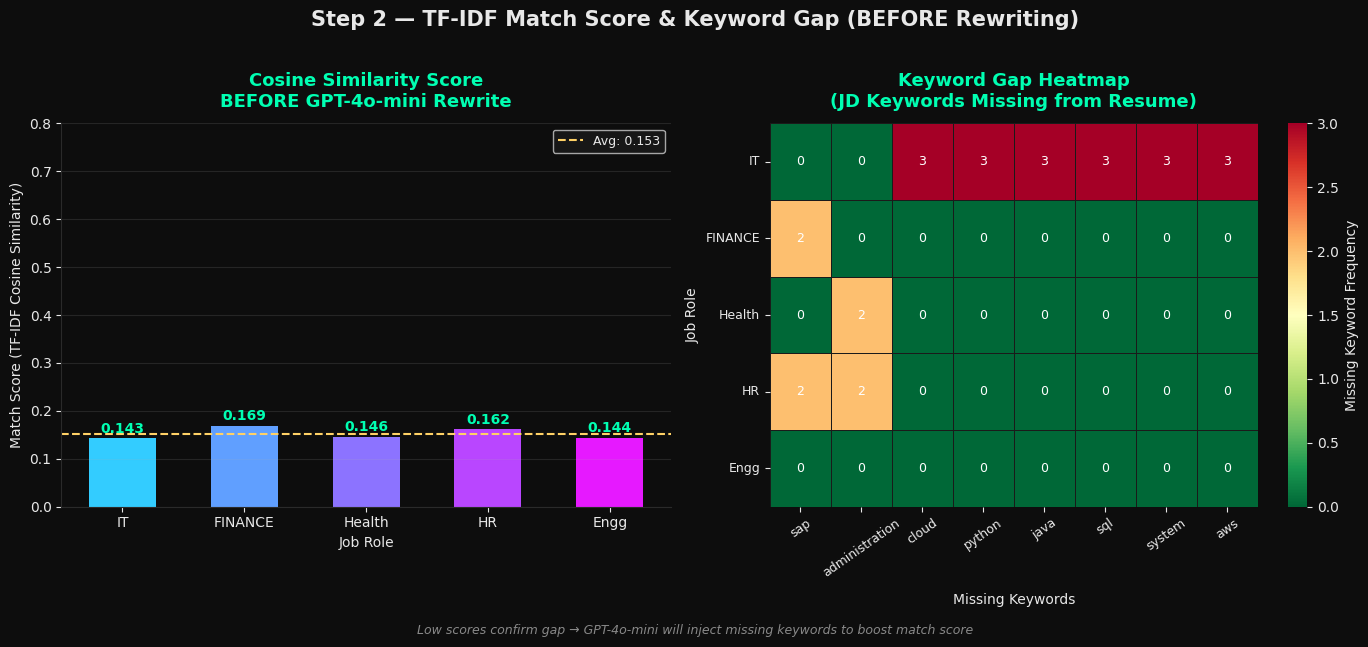


✅ Fig 5 saved → fig5_before_scores.png


In [37]:
# ── 8. VISUALIZATIONS ─────────────────────────────────────────────────────────
BG      = "#0D0D0D"
ACCENT1 = "#00FFB2"
ACCENT2 = "#FF4D6D"
ACCENT3 = "#FFD166"
TEXT    = "#E8E8E8"

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': TEXT, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'axes.edgecolor': '#2A2A2A',
})

roles_list  = list(before_scores.keys())
scores_list = list(before_scores.values())
short_roles = [r.replace('INFORMATION-TECHNOLOGY', 'IT')
                .replace('HEALTHCARE', 'Health')
                .replace('ENGINEERING', 'Engg')
               for r in roles_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)

# ── Plot A: Before Match Score Bar ────────────────────────────────────────────
ax = axes[0]
bar_colors = plt.cm.cool(np.linspace(0.2, 0.9, len(roles_list)))
bars = ax.bar(short_roles, scores_list, color=bar_colors,
              edgecolor='none', width=0.55)

for bar, val in zip(bars, scores_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=10, color=ACCENT1, fontweight='bold')

ax.axhline(y=np.mean(scores_list), color=ACCENT3, linestyle='--',
           lw=1.5, label=f'Avg: {np.mean(scores_list):.3f}')
ax.set_ylim(0, 0.8)
ax.set_title('Cosine Similarity Score\nBEFORE GPT-4o-mini Rewrite',
             fontsize=13, fontweight='bold', color=ACCENT1, pad=12)
ax.set_ylabel('Match Score (TF-IDF Cosine Similarity)', fontsize=10)
ax.set_xlabel('Job Role', fontsize=10)
ax.legend(fontsize=9, facecolor='#1A1A1A')
ax.grid(axis='y', alpha=0.15)
ax.spines[['top', 'right']].set_visible(False)

# ── Plot B: Keyword Gap Heatmap ───────────────────────────────────────────────
ax = axes[1]

all_gap_words = []
for role in gap_results:
    all_gap_words.extend([w for w, _ in gap_results[role]])
top_words = [w for w, _ in Counter(all_gap_words).most_common(8)]

gap_matrix = []
for role in roles_list:
    gap_dict = dict(gap_results[role])
    gap_matrix.append([gap_dict.get(w, 0) for w in top_words])

gap_df = pd.DataFrame(gap_matrix, index=short_roles, columns=top_words)

sns.heatmap(gap_df, ax=ax, cmap='RdYlGn_r',
            linewidths=0.5, linecolor='#1A1A1A',
            annot=True, fmt='d',
            annot_kws={'size': 9, 'color': 'white'},
            cbar_kws={'label': 'Missing Keyword Frequency'})

ax.set_title('Keyword Gap Heatmap\n(JD Keywords Missing from Resume)',
             fontsize=13, fontweight='bold', color=ACCENT1, pad=12)
ax.set_xlabel('Missing Keywords', fontsize=10, labelpad=10)
ax.set_ylabel('Job Role', fontsize=10)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

fig.suptitle('Step 2 — TF-IDF Match Score & Keyword Gap (BEFORE Rewriting)',
             fontsize=15, fontweight='bold', color=TEXT, y=1.02)
fig.text(0.5, -0.02,
         'Low scores confirm gap → GPT-4o-mini will inject missing keywords to boost match score',
         ha='center', fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('fig5_before_scores.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("\n✅ Fig 5 saved → fig5_before_scores.png")


In [39]:
# ── 9. SUMMARY TABLE ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Role'         : roles_list,
    'Resume_Chars' : [len(selected_resumes[r]) for r in roles_list],
    'JD_Chars'     : [len(generated_jds[r])    for r in roles_list],
    'Before_Score' : scores_list,
    'Missing_KWs'  : [len(gap_results[r])       for r in roles_list],
    'Status'       : ['Needs Rewriting ❌' if s < 0.5 else 'Acceptable ⚠️'
                      for s in scores_list]
})

print("\n📋 STEP 2 SUMMARY:\n")
print(summary.to_string(index=False))

summary.to_csv('step2_before_scores.csv', index=False)
print("\n✅ CSV saved → step2_before_scores.csv")

print("\n" + "="*60)
print("   Scores calculated BEFORE GPT-4o-mini rewriting.")
print("="*60)


📋 STEP 2 SUMMARY:

                  Role  Resume_Chars  JD_Chars  Before_Score  Missing_KWs            Status
INFORMATION-TECHNOLOGY          3000      1467        0.1426           10 Needs Rewriting ❌
               FINANCE          3000      1428        0.1686           10 Needs Rewriting ❌
            HEALTHCARE          3000      1524        0.1459           10 Needs Rewriting ❌
                    HR          3000      1493        0.1622           10 Needs Rewriting ❌
           ENGINEERING          3000      1448        0.1440           10 Needs Rewriting ❌

✅ CSV saved → step2_before_scores.csv

   Scores calculated BEFORE GPT-4o-mini rewriting.


In [40]:
from google.colab import files

files.download('fig5_before_scores.png')
files.download('step2_before_scores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>